# Quantum Neural Network Classifier

Binary classification on the Iris dataset using a `NeuralNetworkClassifier` built on
an `EstimatorQNN` from `qiskit-machine-learning`.

Results are saved to `qnn_results.json` for use in `comparison/comparison.ipynb`.

---

## How a QNN classifier works

A classical MLP stacks layers of neurons: each neuron computes a weighted sum of its
inputs and applies a non-linear activation function. Training adjusts those weights
via backpropagation.

A QNN replaces those layers with a parameterized quantum circuit (PQC) split into:

1. **Feature map**: encodes classical input data `x` into a quantum state `|φ(x)⟩`
   using rotation gates whose angles are set by the input values.
2. **Ansatz**: a trainable circuit `W(θ)` whose gate angles `θ` are the learnable
   parameters, analogous to the weights of a classical network.

The output is produced by `EstimatorQNN`, which computes the **expectation value**
of an observable (the Z operator on the first qubit) on the final state `W(θ)|φ(x)⟩`.
This gives a real number in [-1, 1] per sample.

`NeuralNetworkClassifier` wraps the QNN and interprets that number as a class score:
values above 0 → class 1, values below 0 → class 0.

Training minimizes a loss function (cross-entropy) by adjusting `θ` using the
**parameter-shift rule** to compute gradients — the quantum analogue of backpropagation.

**Key difference from VQC:**  
`VQC` is a ready-made high-level class. `NeuralNetworkClassifier` + `EstimatorQNN`
requires building the QNN manually, which exposes the internal architecture and
gives explicit control over the observable, the gradient method, and the optimizer.

---

**Configuration variable:** `N_FEATURES` controls how many features (and qubits) are used.  
**Hardware:** Training runs on the Aer simulator. Set `RUN_ON_REAL_HW = True` to evaluate
the trained model on IBM Quantum hardware.

## Imports

In [19]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit.quantum_info import SparsePauliOp

from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.algorithms import NeuralNetworkClassifier
from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B

from qiskit_aer.primitives import EstimatorV2 as AerEstimator

## Configuration

In [20]:
N_FEATURES     = 2       # 2 or 4 — must match mlp.ipynb
TEST_SIZE      = 0.2     # must match mlp.ipynb
RANDOM_SEED    = 42      # must match mlp.ipynb
MAX_ITER       = 150     # optimizer iterations
RUN_ON_REAL_HW = True    # set True to evaluate on IBM Quantum after training

RESULTS_FILE = "qnn_results.json" if N_FEATURES == 2 else "qnn_results_4f.json"

print(f"Configuration: N_FEATURES={N_FEATURES}, MAX_ITER={MAX_ITER}, RUN_ON_REAL_HW={RUN_ON_REAL_HW}")
print(f"Results will be saved to: {RESULTS_FILE}")

Configuration: N_FEATURES=2, MAX_ITER=150, RUN_ON_REAL_HW=True
Results will be saved to: qnn_results.json


## Dataset

Identical preprocessing to `mlp.ipynb` — same seed, same split, same scaling.  
Features are scaled to [0, π] so they span the full rotation range of the feature map gates.

Labels are remapped to {-1, +1} instead of {0, 1} to match the output range of
`EstimatorQNN` (expectation value in [-1, 1]).

In [21]:
iris = load_iris()

mask   = iris.target != 0
X_full = iris.data[mask]
y_full = iris.target[mask] - 1        # {0, 1}

if N_FEATURES == 2:
    X = X_full[:, 2:4]
    feature_names = ["petal length", "petal width"]
else:
    X = X_full
    feature_names = list(iris.feature_names)

scaler      = MinMaxScaler()
X_scaled    = scaler.fit_transform(X)
X_scaled_pi = X_scaled * np.pi

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_pi, y_full, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_full
)

# Remap labels to {-1, +1} for the EstimatorQNN output range
y_train_pm = 2 * y_train - 1          # {0,1} -> {-1,+1}
y_test_pm  = 2 * y_test  - 1

print(f"Total samples : {len(X_scaled_pi)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")
print(f"Features      : {feature_names}")
print(f"Label encoding: 0 -> -1 (Versicolor), 1 -> +1 (Virginica)")

Total samples : 100
Train samples : 80
Test samples  : 20
Features      : ['petal length', 'petal width']
Label encoding: 0 -> -1 (Versicolor), 1 -> +1 (Virginica)


## Quantum Circuit Architecture

**Feature map — `ZZFeatureMap` (reps=2)**  
Same as in the VQC and QKSVM experiments, for consistency.

**Ansatz — `RealAmplitudes` (reps=3)**  
Same as in the VQC experiment.

**Observable — `Z` on qubit 0**  
The expectation value ⟨Z₀⟩ is computed on the first qubit after applying the full circuit.
This is the scalar output of the QNN for each input sample.
Z has eigenvalues +1 (state |0⟩) and -1 (state |1⟩), so the output is naturally in [-1, 1],
matching the {-1, +1} label encoding.

Number of qubits     : 2
Trainable parameters : 8
Observable           : IZ (Z on qubit 0)


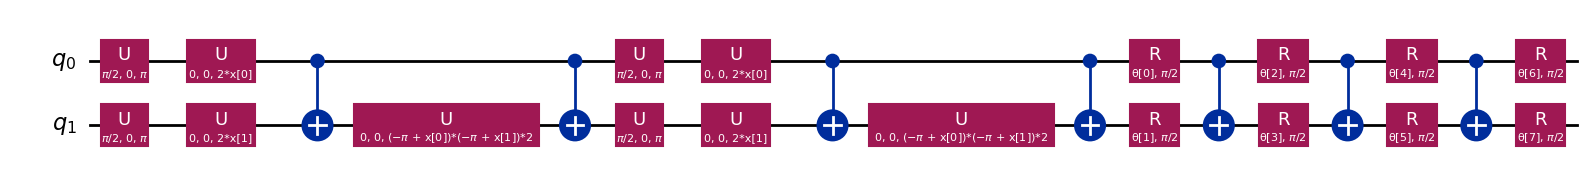

In [22]:
n_qubits    = N_FEATURES
feature_map = zz_feature_map(feature_dimension=n_qubits, reps=2)
ansatz      = real_amplitudes(num_qubits=n_qubits, reps=3)

# Full circuit: feature map followed by ansatz
from qiskit.circuit import QuantumCircuit
qc = QuantumCircuit(n_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

# Observable: Z operator on qubit 0
# 'Z' + 'I'*(n_qubits-1) builds the string e.g. 'IZ' for 2 qubits
observable_str = "I" * (n_qubits - 1) + "Z"
observable     = SparsePauliOp(observable_str)

print(f"Number of qubits     : {n_qubits}")
print(f"Trainable parameters : {ansatz.num_parameters}")
print(f"Observable           : {observable_str} (Z on qubit 0)")

qc.decompose().draw(output="mpl", fold=-1)

## Build EstimatorQNN and NeuralNetworkClassifier

In [23]:
estimator = AerEstimator()

qnn = EstimatorQNN(
    circuit        = qc,
    estimator      = estimator,
    observables    = observable,
    input_params   = feature_map.parameters,
    weight_params  = ansatz.parameters,
)

# Track loss during training
loss_history = []

def callback(weights, obj_func_eval):
    loss_history.append(obj_func_eval)
    if len(loss_history) % 10 == 0:
        print(f"  Iteration {len(loss_history):>4} | Loss: {obj_func_eval:.4f}")

classifier = NeuralNetworkClassifier(
    neural_network = qnn,
    optimizer      = COBYLA(maxiter=MAX_ITER),
    loss           = "cross_entropy",
    callback       = callback,
    initial_point  = np.random.default_rng(RANDOM_SEED).uniform(
                         -np.pi, np.pi, ansatz.num_parameters
                     ),
)

print(f"QNN input parameters  : {len(feature_map.parameters)}")
print(f"QNN weight parameters : {len(ansatz.parameters)}")
print(f"Optimizer             : COBYLA (max {MAX_ITER} iterations)")
print(f"Loss function         : cross-entropy")

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


QNN input parameters  : 2
QNN weight parameters : 8
Optimizer             : COBYLA (max 150 iterations)
Loss function         : cross-entropy


## Training on Aer Simulator

In [24]:
print(f"Training QNN on Aer simulator ({MAX_ITER} max iterations)...")
t0 = time.perf_counter()
classifier.fit(X_train, y_train_pm)
train_time_sim = time.perf_counter() - t0

print(f"\nTraining completed in {train_time_sim:.2f} s")
print(f"Final loss: {loss_history[-1]:.4f}")

Training QNN on Aer simulator (150 max iterations)...
  Iteration   10 | Loss: -4.1529
  Iteration   20 | Loss: -5.0210
  Iteration   30 | Loss: -6.6936
  Iteration   40 | Loss: -7.4012
  Iteration   50 | Loss: -6.6965
  Iteration   60 | Loss: -7.0483
  Iteration   70 | Loss: -7.0257

Training completed in 1.37 s
Final loss: -7.3598


## Evaluation on Simulator

In [25]:
# Predictions come back as {-1, +1} — remap to {0, 1} for consistent reporting
y_pred_train_pm  = classifier.predict(X_train)
y_pred_test_pm   = classifier.predict(X_test)

y_pred_train_sim = ((y_pred_train_pm + 1) / 2).astype(int)
y_pred_test_sim  = ((y_pred_test_pm  + 1) / 2).astype(int)

acc_train_sim = accuracy_score(y_train, y_pred_train_sim)
acc_test_sim  = accuracy_score(y_test,  y_pred_test_sim)

print(f"Train accuracy (simulator): {acc_train_sim:.4f}")
print(f"Test accuracy  (simulator): {acc_test_sim:.4f}")
print()
print(classification_report(y_test, y_pred_test_sim,
                             target_names=["Versicolor", "Virginica"]))

Train accuracy (simulator): 0.7375
Test accuracy  (simulator): 0.5500

              precision    recall  f1-score   support

  Versicolor       0.55      0.60      0.57        10
   Virginica       0.56      0.50      0.53        10

    accuracy                           0.55        20
   macro avg       0.55      0.55      0.55        20
weighted avg       0.55      0.55      0.55        20



## Evaluation on IBM Quantum Hardware (optional)

The model is **trained** on the simulator and **evaluated** on real hardware.
A new `EstimatorQNN` is built pointing to the real backend, and the trained weights
are transferred to it before running inference.

Set `RUN_ON_REAL_HW = True` in the Configuration cell to enable this section.

In [26]:
acc_test_real    = None
y_pred_test_real = None
backend_name     = None

if RUN_ON_REAL_HW:
    from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as RealEstimator
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False,
                                  min_num_qubits=n_qubits)
    backend_name = backend.name
    print(f"Using backend: {backend_name}")

    # IBM requires ISA circuits (hardware-native gate set) since March 2024.
    # Transpile qc and remap the observable to match the physical qubit layout.
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit    = pm.run(qc)
    isa_observable = observable.apply_layout(isa_circuit.layout)

    real_estimator = RealEstimator(backend)

    qnn_real = EstimatorQNN(
        circuit       = isa_circuit,
        estimator     = real_estimator,
        observables   = isa_observable,
        input_params  = feature_map.parameters,
        weight_params = ansatz.parameters,
    )

    trained_weights = classifier.weights

    print("Running inference on real hardware...")
    t0 = time.perf_counter()
    raw_output = qnn_real.forward(X_test, trained_weights)
    infer_time_real = time.perf_counter() - t0

    # raw_output shape: (n_samples, 1), expectation values in [-1, 1]
    # Threshold at 0 → {-1, +1}, then remap to {0, 1}
    y_pred_real_pm   = np.where(raw_output.flatten() >= 0, 1, -1)
    y_pred_test_real = ((y_pred_real_pm + 1) // 2).astype(int)
    acc_test_real    = accuracy_score(y_test, y_pred_test_real)

    print(f"Test accuracy (real HW): {acc_test_real:.4f}")
    print(f"Inference time         : {infer_time_real:.2f} s")
else:
    print("RUN_ON_REAL_HW is False — skipping real hardware evaluation.")
    print("Set RUN_ON_REAL_HW = True in the Configuration cell to enable.")

Using backend: ibm_fez


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Running inference on real hardware...
Test accuracy (real HW): 0.5500
Inference time         : 46.60 s


## Plots

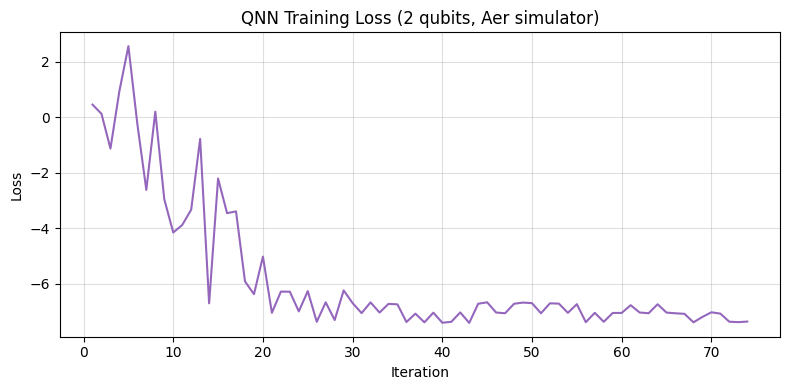

In [27]:
# --- Loss curve ---
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, color="tab:purple")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title(f"QNN Training Loss ({n_qubits} qubits, Aer simulator)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"qnn_loss_curve{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

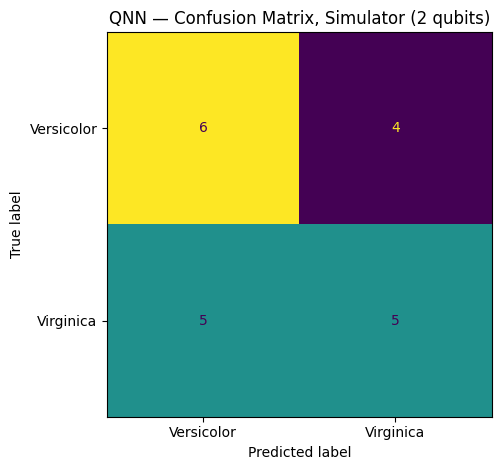

In [28]:
# --- Confusion matrix ---
cm   = confusion_matrix(y_test, y_pred_test_sim)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Versicolor", "Virginica"])
disp.plot(colorbar=False)
plt.title(f"QNN — Confusion Matrix, Simulator ({n_qubits} qubits)")
plt.tight_layout()
plt.savefig(f"qnn_confusion_matrix_sim{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

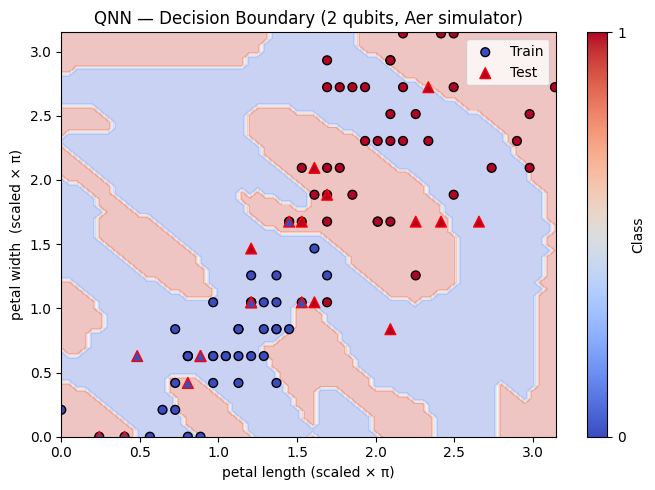

In [29]:
# --- Decision boundary (only for 2 features) ---
if N_FEATURES == 2:
    h = 0.05   # coarser grid — each point requires a circuit evaluation
    xx, yy = np.meshgrid(np.arange(0, np.pi + h, h), np.arange(0, np.pi + h, h))
    grid   = np.c_[xx.ravel(), yy.ravel()]

    Z_pm = classifier.predict(grid)
    Z    = ((Z_pm + 1) / 2).astype(int).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
                          cmap="coolwarm", edgecolors="k", s=40, label="Train")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test,
                cmap="coolwarm", edgecolors="r", s=60, marker="^", label="Test")
    plt.colorbar(scatter, ticks=[0, 1], label="Class")
    plt.xlabel("petal length (scaled × π)")
    plt.ylabel("petal width  (scaled × π)")
    plt.title("QNN — Decision Boundary (2 qubits, Aer simulator)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("qnn_decision_boundary.png", dpi=150)
    plt.show()
else:
    print("Decision boundary plot skipped (only available for N_FEATURES=2).")

## Save Results

In [30]:
results = {
    # --- Experiment metadata ---
    "model"               : "QNN",
    "n_features"          : N_FEATURES,
    "n_qubits"            : n_qubits,
    "feature_names"       : feature_names,
    "n_train"             : int(len(X_train)),
    "n_test"              : int(len(X_test)),
    "random_seed"         : RANDOM_SEED,
    # --- Architecture ---
    "feature_map"         : "ZZFeatureMap",
    "feature_map_reps"    : 2,
    "ansatz"              : "RealAmplitudes",
    "ansatz_reps"         : 3,
    "observable"          : observable_str,
    "n_parameters"        : int(ansatz.num_parameters),
    "optimizer"           : "COBYLA",
    "loss"                : "cross_entropy",
    "max_iter"            : MAX_ITER,
    # --- Timing ---
    "train_time_sim_s"    : float(train_time_sim),
    # --- Accuracy (simulator) ---
    "accuracy_test_sim"   : float(acc_test_sim),
    "accuracy_train_sim"  : float(acc_train_sim),
    # --- Loss history ---
    "loss_history"        : [float(l) for l in loss_history],
    # --- Predictions (simulator) ---
    "y_test"              : y_test.tolist(),
    "y_pred_test_sim"     : y_pred_test_sim.tolist(),
    # --- Real hardware ---
    "real_hw_run"         : RUN_ON_REAL_HW,
    "backend_name"        : backend_name,
    "accuracy_test_real"  : float(acc_test_real) if acc_test_real is not None else None,
    "y_pred_test_real"    : y_pred_test_real.tolist() if y_pred_test_real is not None else None,
}

with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_FILE}")
summary_keys = [k for k in results
                if k not in ("loss_history", "y_test", "y_pred_test_sim", "y_pred_test_real")]
print(json.dumps({k: results[k] for k in summary_keys}, indent=2))

Results saved to qnn_results.json
{
  "model": "QNN",
  "n_features": 2,
  "n_qubits": 2,
  "feature_names": [
    "petal length",
    "petal width"
  ],
  "n_train": 80,
  "n_test": 20,
  "random_seed": 42,
  "feature_map": "ZZFeatureMap",
  "feature_map_reps": 2,
  "ansatz": "RealAmplitudes",
  "ansatz_reps": 3,
  "observable": "IZ",
  "n_parameters": 8,
  "optimizer": "COBYLA",
  "loss": "cross_entropy",
  "max_iter": 150,
  "train_time_sim_s": 1.3715307070015115,
  "accuracy_test_sim": 0.55,
  "accuracy_train_sim": 0.7375,
  "real_hw_run": true,
  "backend_name": "ibm_fez",
  "accuracy_test_real": 0.55
}
